In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE

In [84]:
file_path = r"/Users/Berniss/Downloads/data/raw/Base.csv"
df = pd.read_csv(file_path)

### Data Cleaning

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

In [86]:
df.isnull().sum().sum()

0

In [87]:
duplicated_rows = df[df.duplicated()]
print(f"Number of duplicated rows: {len(duplicated_rows)}")
display(duplicated_rows)

Number of duplicated rows: 0


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month


In [88]:
df.describe()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,...,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.0,1000000.000000
mean,0.011029,0.562696,0.493694,16.718568,86.587867,33.689080,1.025705e+00,8.661499,1572.692049,5665.296605,...,0.889676,10.839303,0.222988,515.851010,0.025242,7.544940,0.576947,1.018312,0.0,3.288674
std,0.104438,0.290343,0.289125,44.046230,88.406599,12.025799,5.381835e+00,20.236155,1005.374565,3009.380665,...,0.313293,12.116875,0.416251,487.559902,0.156859,8.033106,0.494044,0.180761,0.0,2.209994
min,0.000000,0.100000,0.000001,-1.000000,-1.000000,10.000000,4.036860e-09,-15.530555,1.000000,-170.603072,...,0.000000,-1.000000,0.000000,190.000000,0.000000,-1.000000,0.000000,-1.000000,0.0,0.000000
25%,0.000000,0.300000,0.225216,-1.000000,19.000000,20.000000,7.193246e-03,-1.181488,894.000000,3436.365848,...,1.000000,-1.000000,0.000000,200.000000,0.000000,3.103053,0.000000,1.000000,0.0,1.000000
50%,0.000000,0.600000,0.492153,-1.000000,52.000000,30.000000,1.517574e-02,-0.830507,1263.000000,5319.769349,...,1.000000,5.000000,0.000000,200.000000,0.000000,5.114321,1.000000,1.000000,0.0,3.000000
75%,0.000000,0.800000,0.755567,12.000000,130.000000,40.000000,2.633069e-02,4.984176,1944.000000,7680.717827,...,1.000000,25.000000,0.000000,500.000000,0.000000,8.866131,1.000000,1.000000,0.0,5.000000
max,1.000000,0.900000,0.999999,383.000000,428.000000,90.000000,7.845690e+01,112.956928,6700.000000,16715.565404,...,1.000000,32.000000,1.000000,2100.000000,1.000000,85.899143,1.000000,2.000000,0.0,7.000000


In [89]:
for column in df.columns:
    unique_count = df[column].nunique()
    print(f"Column: {column}, Unique values: {unique_count}")

Column: fraud_bool, Unique values: 2
Column: income, Unique values: 9
Column: name_email_similarity, Unique values: 998861
Column: prev_address_months_count, Unique values: 374
Column: current_address_months_count, Unique values: 423
Column: customer_age, Unique values: 9
Column: days_since_request, Unique values: 989330
Column: intended_balcon_amount, Unique values: 994971
Column: payment_type, Unique values: 5
Column: zip_count_4w, Unique values: 6306
Column: velocity_6h, Unique values: 998687
Column: velocity_24h, Unique values: 998940
Column: velocity_4w, Unique values: 998318
Column: bank_branch_count_8w, Unique values: 2326
Column: date_of_birth_distinct_emails_4w, Unique values: 40
Column: employment_status, Unique values: 7
Column: credit_risk_score, Unique values: 551
Column: email_is_free, Unique values: 2
Column: housing_status, Unique values: 7
Column: phone_home_valid, Unique values: 2
Column: phone_mobile_valid, Unique values: 2
Column: bank_months_count, Unique values: 3

### EDA

- **income (numeric)**: Annual income of the applicant (in decile form). Ranges between [0.1, 0.9].
- **name_email_similarity (numeric)**: Metric of similarity between email and applicant’s name. Higher values represent higher similarity. Ranges between [0, 1].
- **prev_address_months_count (numeric)**: Number of months in previous registered address of the applicant. Ranges between [−1, 380] months (-1 is a missing value).
- **current_address_months_count (numeric)**: Months in currently registered address of the applicant. Ranges between [−1, 429] months (-1 is a missing value).
- **customer_age (numeric)**: Applicant’s age in years, rounded to the decade. Ranges between [10, 90] years.
- **days_since_request (numeric)**: Number of days passed since application was done. Ranges between [0, 79] days.
- **intended_balcon_amount (numeric)**: Initial transferred amount for application. Ranges between [−16, 114] (negatives are missing values).
- **payment_type (categorical)**: Credit payment plan type. 5 possible (anonymized) values.
- **zip_count_4w (numeric)**: Number of applications within the same zip code in the last 4 weeks. Ranges between [1, 6830].
- **velocity_6h (numeric)**: Velocity of total applications made in the last 6 hours, i.e., average number of applications per hour in the last 6 hours. Ranges between [−175, 16818].
- **velocity_24h (numeric)**: Velocity of total applications made in the last 24 hours, i.e., average number of applications per hour in the last 24 hours. Ranges between [1297, 9586].
- **velocity_4w (numeric)**: Velocity of total applications made in the last 4 weeks, i.e., average number of applications per hour in the last 4 weeks. Ranges between [2825, 7020].
- **bank_branch_count_8w (numeric)**: Number of total applications in the selected bank branch in the last 8 weeks. Ranges between [0, 2404].
- **date_of_birth_distinct_emails_4w (numeric)**: Number of emails for applicants with the same date of birth in the last 4 weeks. Ranges between [0, 39].
- **employment_status (categorical)**: Employment status of the applicant. 7 possible (anonymized) values.
- **credit_risk_score (numeric)**: Internal score of application risk. Ranges between [−191, 389].
- **email_is_free (binary)**: Domain of application email (either free or paid).
- **housing_status (categorical)**: Current residential status for the applicant. 7 possible (anonymized) values.
- **phone_home_valid (binary)**: Validity of provided home phone.
- **phone_mobile_valid (binary)**: Validity of provided mobile phone.
- **bank_months_count (numeric)**: How old is the previous account (if held) in months. Ranges between [−1, 32] months (-1 is a missing value).
- **has_other_cards (binary)**: If the applicant has other cards from the same banking company.
- **proposed_credit_limit (numeric)**: Applicant’s proposed credit limit. Ranges between [200, 2000].
- **foreign_request (binary)**: If the origin country of request is different from the bank’s country.
- **source (categorical)**: Online source of application. Either browser (INTERNET) or app (TELEAPP).
- **session_length_in_minutes (numeric)**: Length of user session in banking website in minutes. Ranges between [−1, 107] minutes (-1 is a missing value).
- **device_os (categorical)**: Operating system of the device that made the request. Possible values are: Windows, macOS, Linux, X11, or other.
- **keep_alive_session (binary)**: User option on session logout.
- **device_distinct_emails (numeric)**: Number of distinct emails in banking website from the used device in the last 8 weeks. Ranges between [−1, 2] emails (-1 is a missing value).
- **device_fraud_count (numeric)**: Number of fraudulent applications with the used device. Ranges between [0, 1].
- **month (numeric)**: Month when the application was made. Ranges between [0, 7].
- **fraud_bool (binary)**: If the application is fraudulent or not.

In [90]:
### Handle missing values

# 1. Create missing flags for address features
df['prev_address_missing'] = (df['prev_address_months_count'] == -1).astype(int)
df['current_address_missing'] = (df['current_address_months_count'] == -1).astype(int)

# 2. Replace -1 in address features with median
df['prev_address_months_count'] = df['prev_address_months_count'].replace(-1, np.nan)
df['prev_address_months_count'] = df['prev_address_months_count'].fillna(df['prev_address_months_count'].median())

df['current_address_months_count'] = df['current_address_months_count'].replace(-1, np.nan)
df['current_address_months_count'] = df['current_address_months_count'].fillna(df['current_address_months_count'].median())

# 3. Replace < 0 in intended_balcon_amount with median
df['intended_balcon_amount'] = df['intended_balcon_amount'].apply(lambda x: np.nan if x < 0 else x)
df['intended_balcon_amount'] = df['intended_balcon_amount'].fillna(df['intended_balcon_amount'].median())

# 4. Replace -1 in bank_months_count with median
df['bank_months_count'] = df['bank_months_count'].replace(-1, np.nan)
df['bank_months_count'] = df['bank_months_count'].fillna(df['bank_months_count'].median())

# 5. Replace -1 in session_length_in_minutes with median
df['session_length_in_minutes'] = df['session_length_in_minutes'].replace(-1, np.nan)
df['session_length_in_minutes'] = df['session_length_in_minutes'].fillna(df['session_length_in_minutes'].median())

# 6. Replace -1 in device_distinct_emails with 0
df['device_distinct_emails_8w'] = df['device_distinct_emails_8w'].replace(-1, 0)

In [91]:
### Verify missing values are replaced

# 1. Check for -1 in prev/current address months
print("Remaining -1s in prev_address_months_count:", (df['prev_address_months_count'] == -1).sum())
print("Remaining -1s in current_address_months_count:", (df['current_address_months_count'] == -1).sum())

# 2. Check for < 0 in intended_balcon_amount
print("Negative values in intended_balcon_amount:", (df['intended_balcon_amount'] < 0).sum())

# 3. Check for -1 in bank_months_count
print("Remaining -1s in bank_months_count:", (df['bank_months_count'] == -1).sum())

# 4. Check for -1 in session_length_in_minutes
print("Remaining -1s in session_length_in_minutes:", (df['session_length_in_minutes'] == -1).sum())

# 5. Check for -1 in device_distinct_emails_8w
print("Remaining -1s in device_distinct_emails_8w:", (df['device_distinct_emails_8w'] == -1).sum())

Remaining -1s in prev_address_months_count: 0
Remaining -1s in current_address_months_count: 0
Negative values in intended_balcon_amount: 0
Remaining -1s in bank_months_count: 0
Remaining -1s in session_length_in_minutes: 0
Remaining -1s in device_distinct_emails_8w: 0


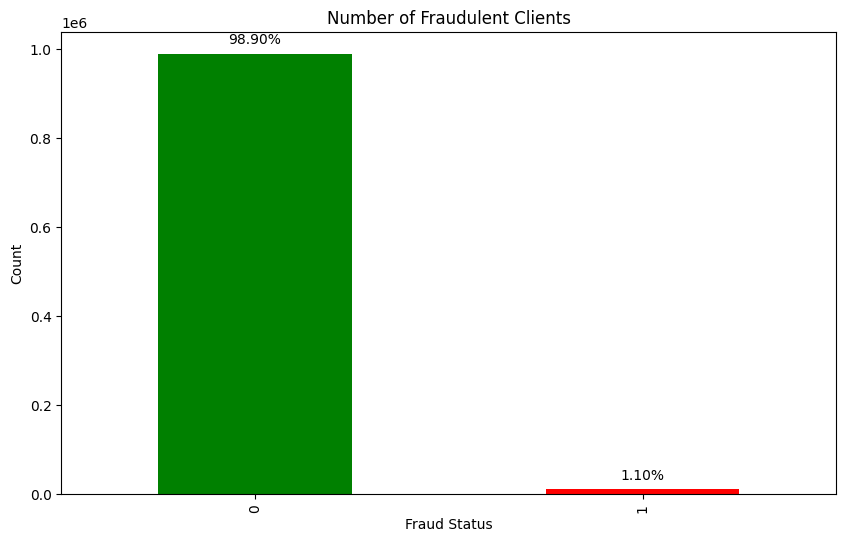

In [92]:
plt.figure(figsize=(10, 6))

# Count the occurrences of each fraud_status
fraud_counts = df['fraud_bool'].value_counts()

# Define colors based on the index
colors = ['green' if index == 0 else 'red' for index in fraud_counts.index]

# Create the bar plot
ax = fraud_counts.plot(kind='bar', color=colors)
plt.title('Number of Fraudulent Clients')
plt.xlabel('Fraud Status')
plt.ylabel('Count')

# Adding percentage on top of the bars
total = len(df)
for p in ax.patches:
    percentage = f'{(p.get_height() / total) * 100:.2f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

In [93]:
numerical_features = [
    "income", "name_email_similarity", "prev_address_months_count", 
    "current_address_months_count", "customer_age", "days_since_request", 
    "intended_balcon_amount", "zip_count_4w", "velocity_6h", "velocity_24h", 
    "velocity_4w", "bank_branch_count_8w", "date_of_birth_distinct_emails_4w", 
    "credit_risk_score", "bank_months_count", "proposed_credit_limit", 
    "session_length_in_minutes", "device_distinct_emails_8w", "device_fraud_count", "month"
]

categorical_features = [
    "payment_type", "employment_status", "housing_status", "source", "device_os",
    "email_is_free", "phone_home_valid", "phone_mobile_valid", 
    "has_other_cards", "foreign_request", "keep_alive_session",
    "prev_address_missing", "current_address_missing" # missing flags
]

target = "fraud_bool"

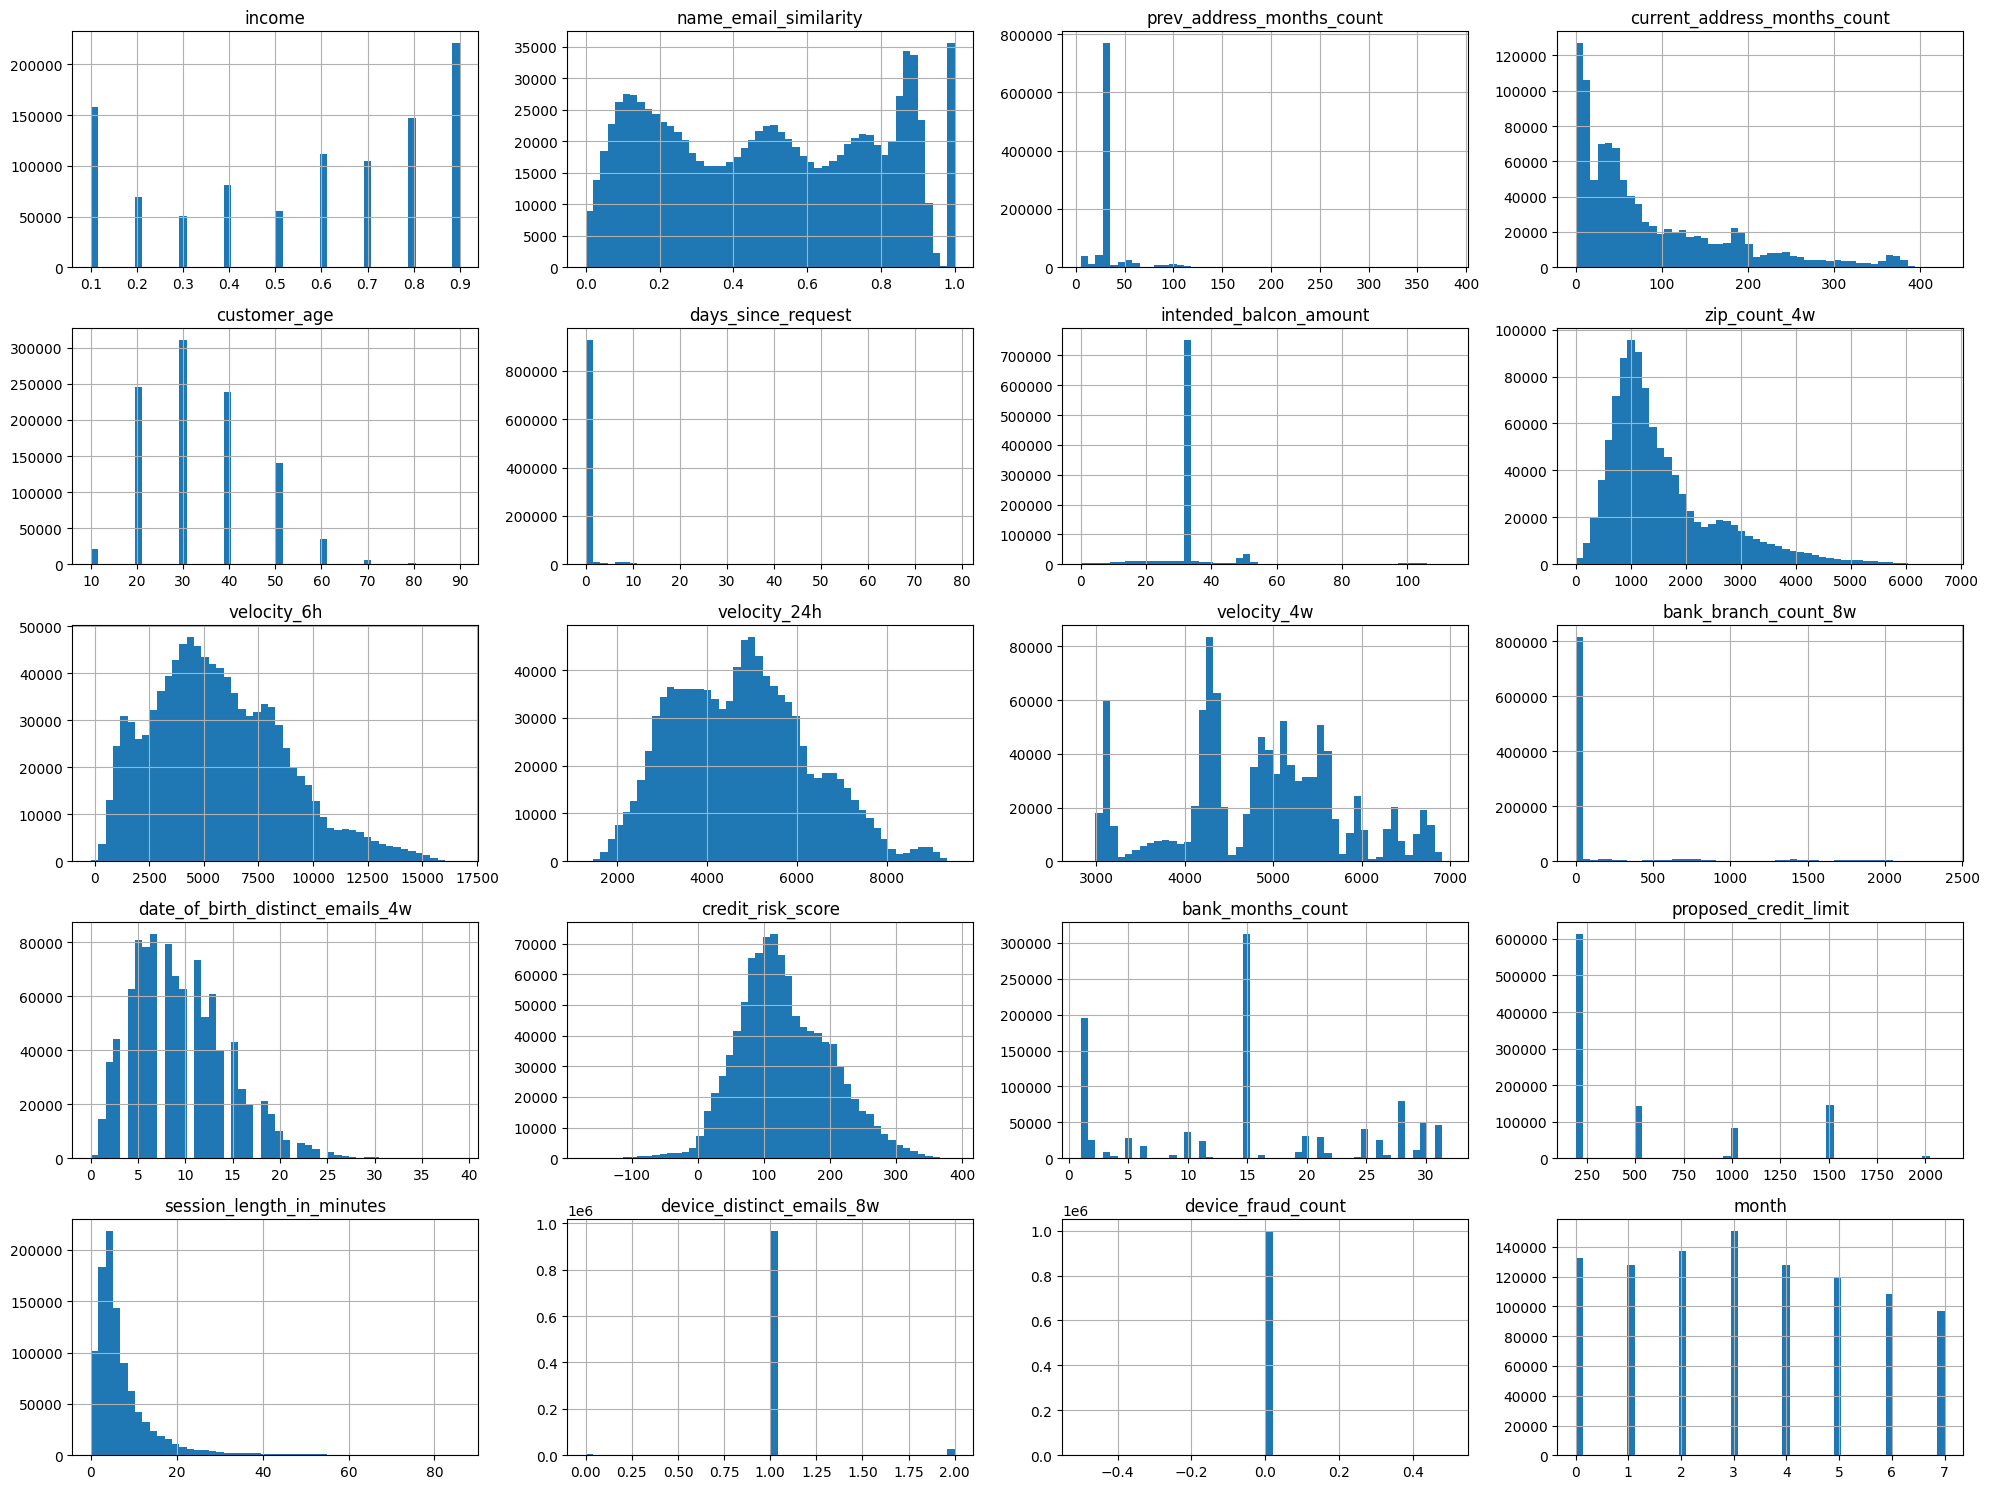

In [94]:
# Plot histograms for numerical columns
df[numerical_features].hist(bins=50, figsize=(20, 15))
plt.tight_layout()
plt.show()

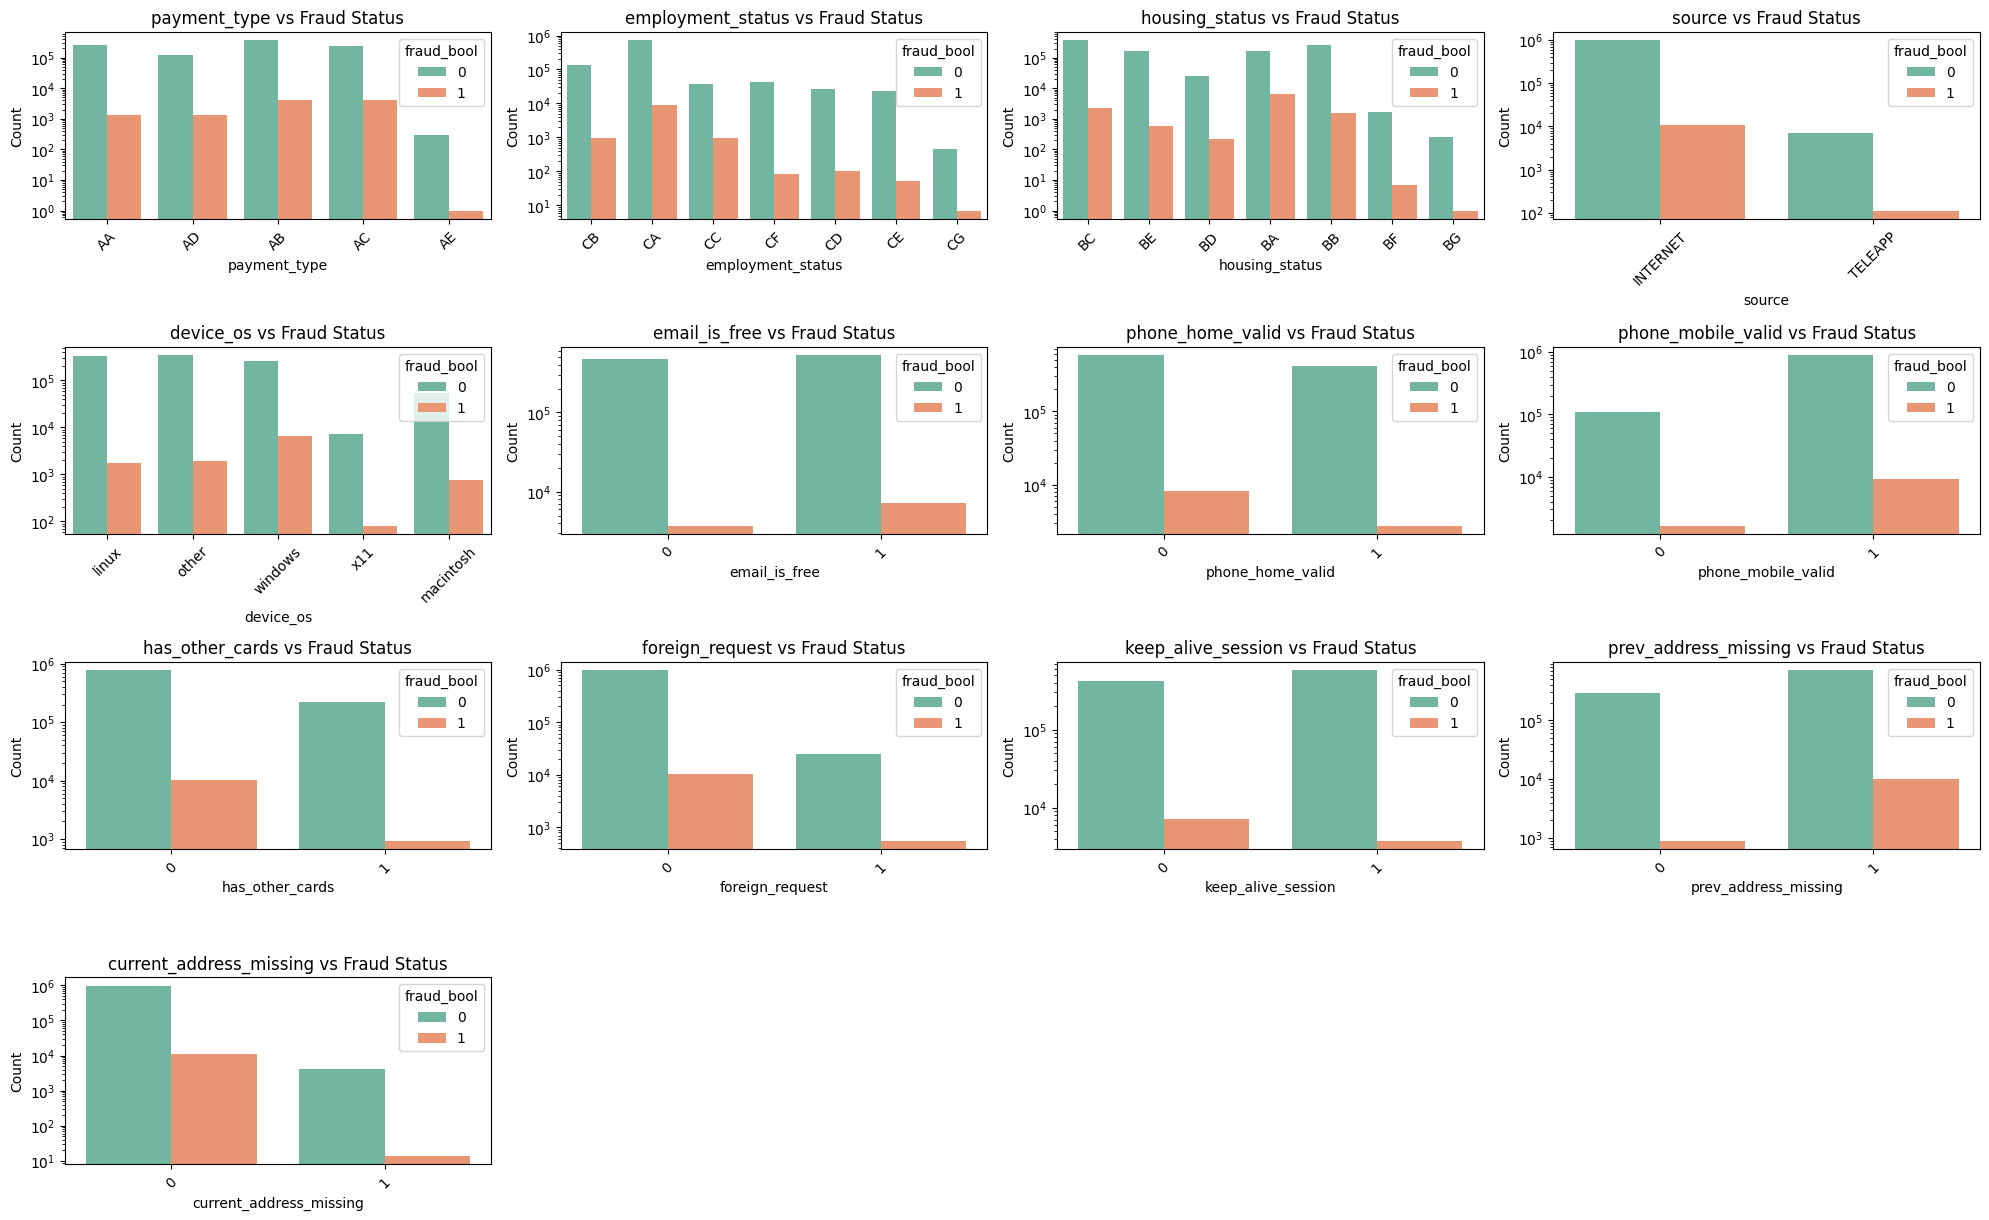

In [95]:
# Define rows and columns for the subplot grid
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 15))

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot categorical features with log scale for count axis
for i, feature in enumerate(categorical_features):
    sns.countplot(
        data=df,
        x=feature,
        hue="fraud_bool",
        palette="Set2",
        ax=axes[i]
    )
    axes[i].set_title(f"{feature} vs Fraud Status", fontsize=12)
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel("Count", fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_yscale('log')  # Apply log scale to the y-axis

# Hide any empty subplots 
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

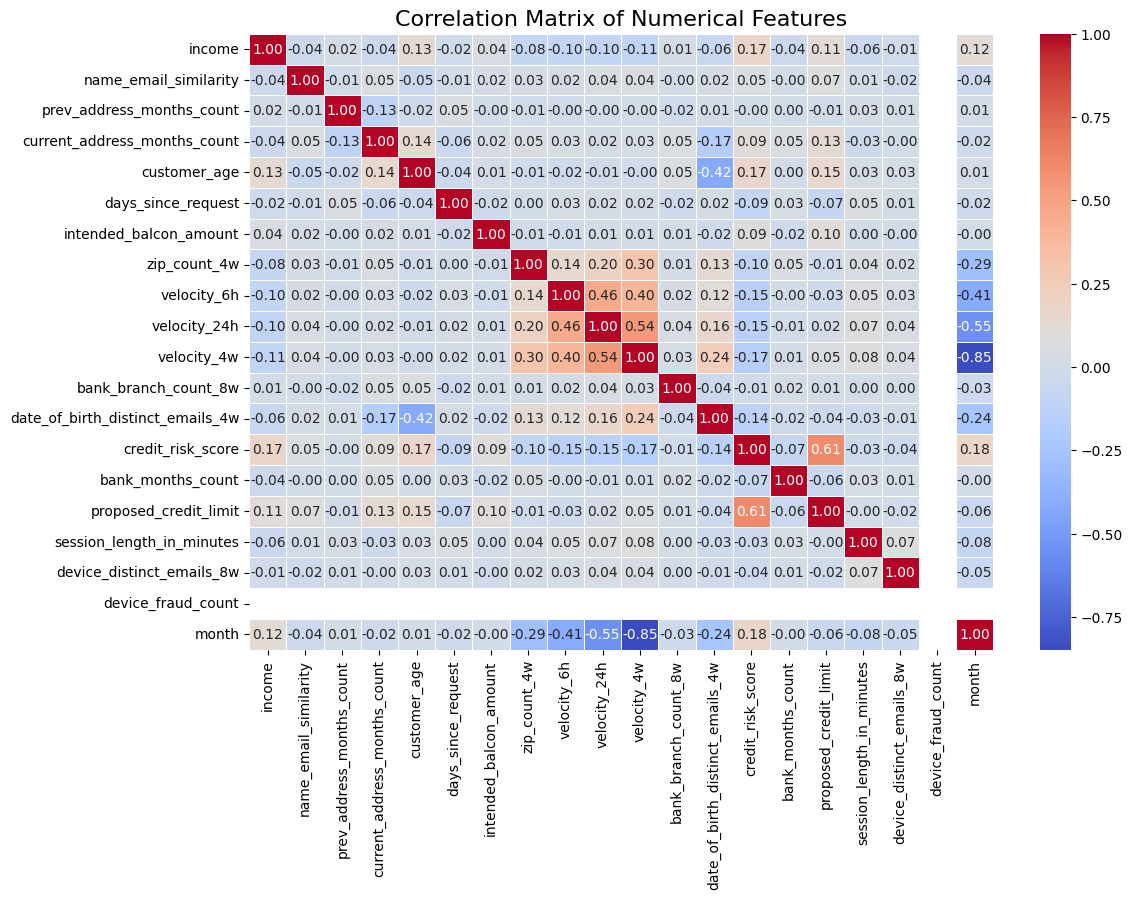

In [96]:
# Correlation matrix for numerical features
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_features].corr(), cmap="coolwarm", annot=True, fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features", fontsize=16)
plt.show()

In [97]:
df['device_fraud_count'].value_counts()

device_fraud_count
0    1000000
Name: count, dtype: int64

### Feature Engineering

In [98]:
df['income'].describe()

count    1000000.000000
mean           0.562696
std            0.290343
min            0.100000
25%            0.300000
50%            0.600000
75%            0.800000
max            0.900000
Name: income, dtype: float64

In [99]:
df['credit_risk_score'].describe()

count    1000000.000000
mean         130.989595
std           69.681812
min         -170.000000
25%           83.000000
50%          122.000000
75%          178.000000
max          389.000000
Name: credit_risk_score, dtype: float64

In [100]:
# 1. Short-Term Velocity Ratio
df['st_velocity_ratio'] = df['velocity_6h'] / (df['velocity_24h'] + 1)

# 2. Long-Term Velocity Ratio
df['lt_velocity_ratio'] = df['velocity_24h'] / (df['velocity_4w'] + 1)

# 3. Total Address Months (sum of previous and current address months)
df['total_address_months'] = df['prev_address_months_count'] + df['current_address_months_count']

# 4. Income Bin (categorizing income into bins)
bins = [0, 0.3, 0.6, 0.8, 1.0]  # Define bins for income
labels = ['Low', 'Medium', 'High', 'Very High']
df['income_bin'] = pd.cut(df['income'], bins=bins, labels=labels, right=False)

# 5. Credit Risk Category (categorizing credit risk score into bins)
df['credit_risk_category'] = pd.cut(
    df['credit_risk_score'],
    bins = [-float('inf'), 83, 178, float('inf')],
    labels=['Low', 'Medium', 'High'],
    right=False
)

# View the first few rows of the dataframe to check the new features
df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,device_distinct_emails_8w,device_fraud_count,month,prev_address_missing,current_address_missing,st_velocity_ratio,lt_velocity_ratio,total_address_months,income_bin,credit_risk_category
0,0,0.3,0.986506,34.0,25.0,40,0.006735,102.453711,AA,1059,...,1,0,0,1,0,1.667869,1.164298,59.0,Medium,Medium
1,0,0.8,0.617426,34.0,89.0,20,0.010095,32.433701,AD,1658,...,1,0,0,1,0,1.605096,0.966780,123.0,Very High,Medium
2,0,0.8,0.996707,9.0,14.0,40,0.012316,32.433701,AB,1095,...,1,0,0,0,0,0.817007,0.912979,23.0,Very High,Medium
3,0,0.6,0.475100,11.0,14.0,30,0.006991,32.433701,AB,3483,...,1,0,0,0,0,2.136065,1.131295,25.0,High,Medium
4,0,0.9,0.842307,34.0,29.0,40,5.742626,47.152498,AA,2339,...,1,0,0,1,0,1.483208,0.862382,63.0,Very High,Medium


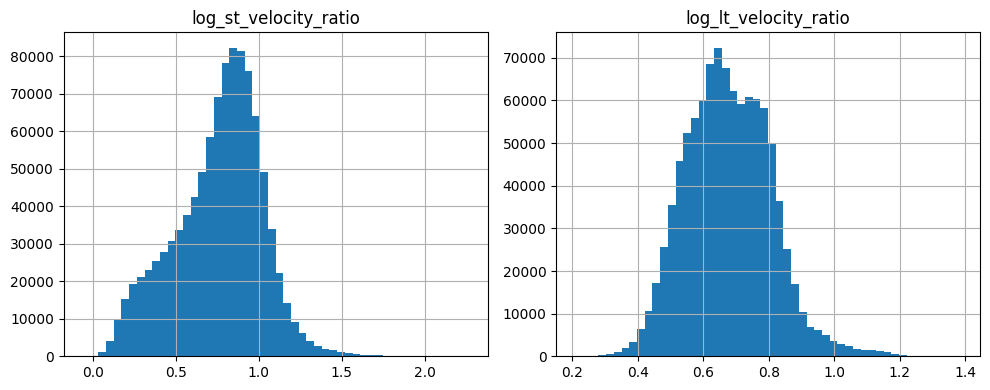

In [101]:
df['log_st_velocity_ratio'] = np.log1p(df['st_velocity_ratio'])
df['log_lt_velocity_ratio'] = np.log1p(df['lt_velocity_ratio'])

df[['log_st_velocity_ratio', 'log_lt_velocity_ratio']].hist(bins=50, figsize=(10, 4))
plt.tight_layout()
plt.show()

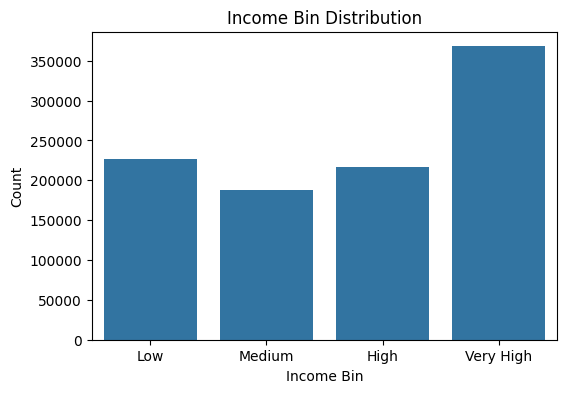

In [102]:
# Count plot for income bin
plt.figure(figsize=(6, 4))
sns.countplot(x='income_bin', data=df, order=labels)
plt.title('Income Bin Distribution')
plt.xlabel('Income Bin')
plt.ylabel('Count')
plt.show()

In [103]:
df.groupby('income_bin')['fraud_bool'].mean()

/var/folders/12/q4wqxhts38d3xk830pbsm9kh0000gp/T/ipykernel_885/83782662.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('income_bin')['fraud_bool'].mean()


income_bin
Low          0.005939
Medium       0.007333
High         0.008799
Very High    0.017369
Name: fraud_bool, dtype: float64

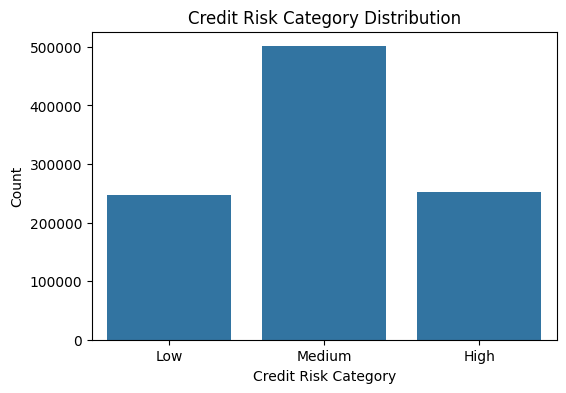

In [104]:
# Count plot for credit risk category
plt.figure(figsize=(6, 4))
sns.countplot(x='credit_risk_category', data=df, order=['Low', 'Medium', 'High'])
plt.title('Credit Risk Category Distribution')
plt.xlabel('Credit Risk Category')
plt.ylabel('Count')
plt.show()

In [105]:
df.groupby('credit_risk_category')['fraud_bool'].mean()

/var/folders/12/q4wqxhts38d3xk830pbsm9kh0000gp/T/ipykernel_885/742224743.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('credit_risk_category')['fraud_bool'].mean()


credit_risk_category
Low       0.006282
Medium    0.007849
High      0.022008
Name: fraud_bool, dtype: float64

In [106]:
# Define training (first 6 months) and testing (last 2 months)
train_df = df[df["month"] <= 6]
test_df = df[df["month"] > 6]

# Define the target variable
target = "fraud_bool"

# Split into features (X) and target (y) for training data
X_train = train_df.drop(columns=[target])
y_train = train_df[target]

# Split into features (X) and target (y) for testing data
X_test = test_df.drop(columns=[target])
y_test = test_df[target]

# Print dataset shapes
print(f"Training Data: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testing Data: X_test = {X_test.shape}, y_test = {y_test.shape}")

Training Data: X_train = (903157, 40), y_train = (903157,)
Testing Data: X_test = (96843, 40), y_test = (96843,)


In [107]:
# Label encode binary features
from sklearn.preprocessing import LabelEncoder
binary_features = [
    "source", "email_is_free", "phone_home_valid", "phone_mobile_valid", 
    "has_other_cards", "foreign_request", "keep_alive_session",
    "prev_address_missing", "current_address_missing"
]

for feature in binary_features:
    le = LabelEncoder()
    X_train[feature] = le.fit_transform(X_train[feature])
    X_test[feature] = le.transform(X_test[feature])

In [108]:
# One-hot encode multi-class categorical features
multi_class_features = [
    "payment_type", "employment_status", "housing_status", "device_os", 
    "income_bin", "credit_risk_category" # new features
]

X_train = pd.get_dummies(X_train, columns=multi_class_features, drop_first=True)
X_test = pd.get_dummies(X_test, columns=multi_class_features, drop_first=True)

In [109]:
# Align the columns of the training and testing sets
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [110]:
numerical_fe_features = [
    "income", "name_email_similarity", "prev_address_months_count", 
    "current_address_months_count", "customer_age", "days_since_request", 
    "intended_balcon_amount", "zip_count_4w", "velocity_6h", "velocity_24h", 
    "velocity_4w", "bank_branch_count_8w", "date_of_birth_distinct_emails_4w", 
    "credit_risk_score", "bank_months_count", "proposed_credit_limit", 
    "session_length_in_minutes", "device_distinct_emails_8w", "device_fraud_count", "month", 
    "log_st_velocity_ratio", "log_lt_velocity_ratio", "total_address_months" # new features
]

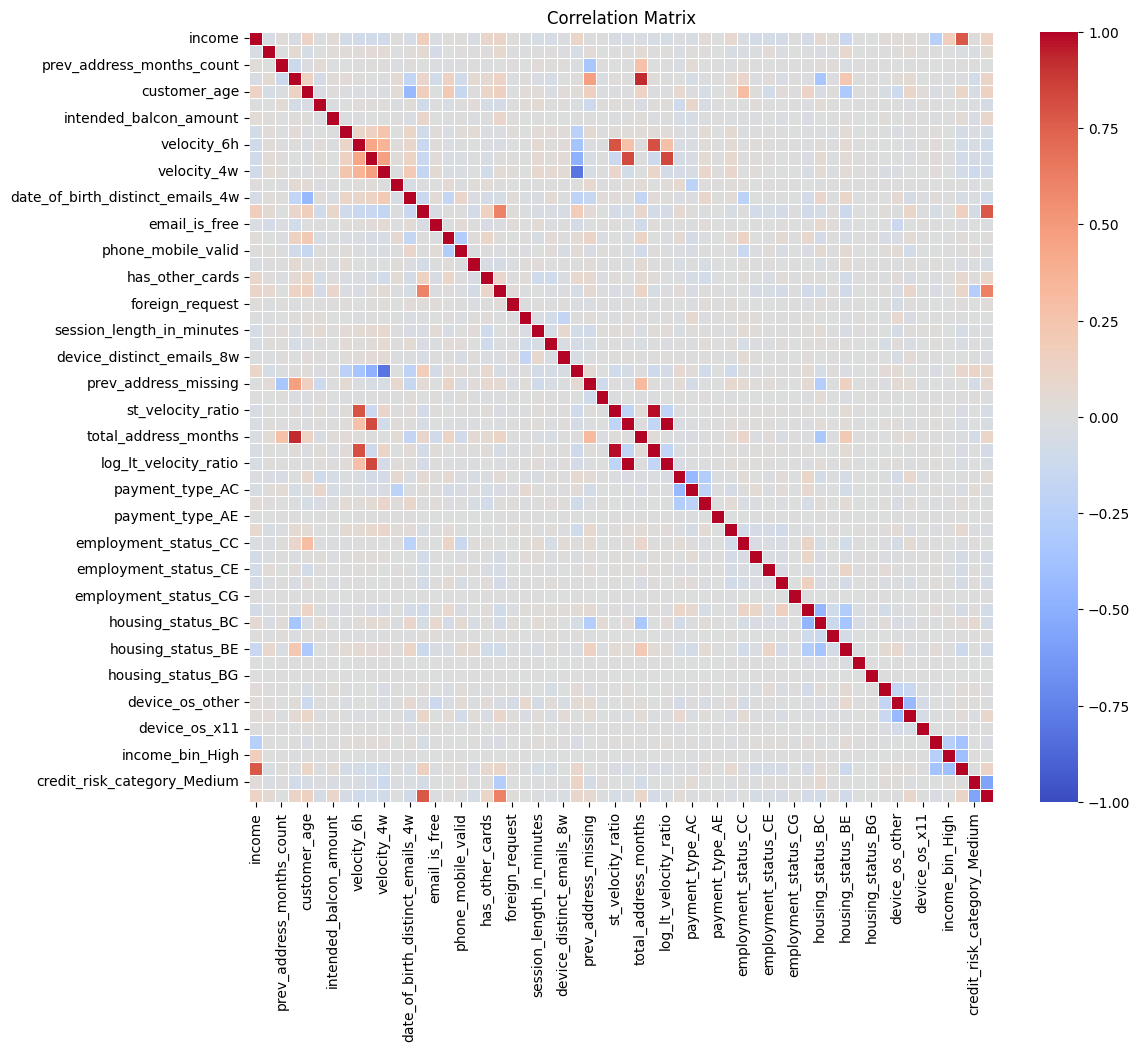

In [111]:
corr_pearson = X_train.drop(["device_fraud_count"], axis=1).corr(method="pearson")

plt.figure(figsize=(12, 10))
sns.heatmap(corr_pearson, annot=False, linewidths=0.5, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

In [112]:
# Identify highly correlated features (correlation >= 0.8 or <= -0.8)
high_corr_var = set()
for i in range(len(corr_pearson.columns)):
    for j in range(i):
        if abs(corr_pearson.iloc[i, j]) > 0.8:  # You can adjust this threshold
            colname = corr_pearson.columns[i]
            high_corr_var.add(colname)

print("Highly correlated features:", high_corr_var)

Highly correlated features: {'total_address_months', 'month', 'log_lt_velocity_ratio', 'lt_velocity_ratio', 'log_st_velocity_ratio'}


In [113]:
# Drop highly correlated features
X_train = X_train.drop(columns= ["st_velocity_ratio", "lt_velocity_ratio"])

### Resampling (SMOTE)

In [ ]:
# Apply Stratified K-Fold Cross-Validation with SMOTE
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote_nc = SMOTE(random_state=42)

for i, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\nFold {i+1}: ")
    
    # Split the data
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    print(f"Train set size before SMOTE: {len(X_fold_train)}")
    print(f"Validation set size: {len(X_fold_val)}")
    print(f"Percentage of fraud in validation set: {y_fold_val.mean():.4f}")

    # Apply SMOTE only to training data
    X_resampled, y_resampled = smote_nc.fit_resample(X_fold_train, y_fold_train)

    print(f"Resampled train set size: {len(X_resampled)}")
    print(f"Percentage of fraud in resampled train set: {y_resampled.mean():.4f}")

    # Save resampled training and validation sets
    fold_val_data = pd.concat([X_fold_val, y_fold_val], axis=1)
    fold_train_data = pd.concat([X_resampled, y_resampled], axis=1)

    fold_val_data.to_csv(f"/Users/Berniss/Downloads/data/preprocessed/fold_{i+1}_val.csv", index=False)
    print("Validation data saved successfully!")

    fold_train_data.to_csv(f"/Users/Berniss/Downloads/data/preprocessed/fold_{i+1}_train.csv", index=False)
    print("Resampled train data saved successfully!\n")


Fold 1: 
Train set size before SMOTE: 722525
Validation set size: 180632
Percentage of fraud in validation set: 0.0106
Resampled train set size: 1429688
Percentage of fraud in resampled train set: 0.5000
Validation data saved successfully!
Resampled train data saved successfully!


Fold 2: 
Train set size before SMOTE: 722525
Validation set size: 180632
Percentage of fraud in validation set: 0.0106
Resampled train set size: 1429690
Percentage of fraud in resampled train set: 0.5000
Validation data saved successfully!
Resampled train data saved successfully!


Fold 3: 
Train set size before SMOTE: 722526
Validation set size: 180631
Percentage of fraud in validation set: 0.0106
Resampled train set size: 1429690
Percentage of fraud in resampled train set: 0.5000
Validation data saved successfully!
Resampled train data saved successfully!


Fold 4: 
Train set size before SMOTE: 722526
Validation set size: 180631
Percentage of fraud in validation set: 0.0106
Resampled train set size: 14296